# Batch Road Accident Severity Modeling with PySpark


# Part 1: Data Loading, Transformation and Exploration <a class="anchor" name="part-1"></a>
## 1.1 Data Loading
In this section, you must load the given datasets into PySpark DataFrames and use DataFrame functions to process the data. For plotting, various visualisation packages can be used, but please ensure that you have included instructions to install the additional packages and that the installation will be successful in the provided Docker container (in case your marker needs to clear the notebook and rerun it).

### 1.1.1 Data Loading <a class="anchor" name="1.1"></a>
1.1.1 Write the code to create a SparkSession. For creating the SparkSession, you need to use a SparkConf object to configure the Spark app with a proper application name, to ensure the maximum partition size does not exceed 32MB, and to run locally with all CPU cores on your machine

In [1]:
from pyspark import SparkConf
from pyspark.sql import SparkSession

conf = (
    SparkConf()
    .setAppName("FIT5202_Assignment2A_Road_Safety_Prediction")
    .setMaster("local[4]")
    .set("spark.sql.files.maxPartitionBytes", str(32 * 1024 * 1024))
    .set("spark.sql.shuffle.partitions", "16")
    .set("spark.driver.memory", "6g")
    .set("spark.driver.maxResultSize", "2g")
)

spark = (
    SparkSession.builder
    .config(conf=conf)
    .getOrCreate()
)

sc = spark.sparkContext
sc.setLogLevel("ERROR")

print("Spark master:", sc.master)
print("Spark app name:", sc.appName)
print("Max partition bytes:", spark.conf.get("spark.sql.files.maxPartitionBytes"))
print("Shuffle partitions:", spark.conf.get("spark.sql.shuffle.partitions"))
print("Driver memory:", sc.getConf().get("spark.driver.memory"))

Spark master: local[4]
Spark app name: FIT5202_Assignment2A_Road_Safety_Prediction
Max partition bytes: 33554432
Shuffle partitions: 16
Driver memory: 6g


In [2]:
# Verify configuration
print("Spark master:", sc.master)
print("Spark app name:", sc.appName)
print("Max partition bytes:", spark.conf.get("spark.sql.files.maxPartitionBytes"))

Spark master: local[4]
Spark app name: FIT5202_Assignment2A_Road_Safety_Prediction
Max partition bytes: 33554432


In [3]:
# Importing Libraries

import matplotlib.pyplot as plt
import statistics
import pyspark.sql.functions as F
import pandas as pd
import seaborn as sns
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, ArrayType, BooleanType, LongType, FloatType
from pyspark.sql.window import Window
from pyspark.ml.feature import Imputer
from IPython.display import Image, display

# Display graphs inside Jupyter Notebook
%matplotlib notebook

1.1.2 Write code to define the schemas for the datasets, following the data types suggested in the metadata file. 

In [4]:
# Columns for the accidents dataset

accident_cols = [
    "collision_index",
    "vehicle_reference",
    "casualty_reference",
    "casualty_class",
    "casualty_severity",
    "pedestrian_location",
    "pedestrian_movement",
    "car_passenger",
    "casualty_type"
]

# # Use string for text columns and integer for the rest
accident_string_cols = {"collision_index"}

accidents_schema = StructType([
    StructField(
        col,
        StringType() if col in accident_string_cols else IntegerType(),
        True
    )
    for col in accident_cols
])

In [5]:
# Columns for the collision dataset

collision_cols = [
    "collision_index",
    "longitude",
    "latitude",
    "date",
    "time",
    "road_type",
    "speed_limit",
    "junction_detail",
    "junction_control",
    "pedestrian_crossing",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "carriageway_hazards",
    "urban_or_rural_area",
    "area"
]

# Use string for text/date columns, double for coordinates, and integer for others
collision_string_cols = {"collision_index", "date", "time", "area"}
collision_double_cols = {"longitude", "latitude"}

collision_schema = StructType([
    StructField(
        col,
        StringType() if col in collision_string_cols else DoubleType() if col in collision_double_cols else IntegerType(),
        True
    )
    for col in collision_cols
])

In [6]:
# Columns for the vehicle dataset

vehicle_cols = [
    "collision_index",
    "vehicle_reference",
    "vehicle_type",
    "vehicle_manoeuvre",
    "junction_location",
    "skidding_and_overturning",
    "hit_object_in_carriageway",
    "first_point_of_impact",
    "sex_of_driver",
    "age_of_driver",
    "engine_capacity_cc",
    "propulsion_code",
    "age_of_vehicle"
]

# Use string for text columns and integer for the rest
vehicle_string_cols = {"collision_index"}

vehicle_schema = StructType([
    StructField(
        col,
        StringType() if col in vehicle_string_cols else IntegerType(),
        True
    )
    for col in vehicle_cols
])

In [7]:
# Columns for the severity rating dataset

severity_cols = [
    "collision_index",
    "severity_rating"
]

# Use string for text columns and integer for the rest
severity_string_cols = {"collision_index"}

severity_schema = StructType([
    StructField(
        col,
        StringType() if col in severity_string_cols else IntegerType(),
        True
    )
    for col in severity_cols
])

1.1.3 Using your schemas, load the CSV files into separate data frames. Print the schemas of all data frames. 

In [8]:
# Load the accident CSV with the schema

df_accidents = spark.read.csv("A2A/A2/a2_accidents.csv", header=True, schema=accidents_schema, sep=',')

In [9]:
df_accidents.printSchema()

root
 |-- collision_index: string (nullable = true)
 |-- vehicle_reference: integer (nullable = true)
 |-- casualty_reference: integer (nullable = true)
 |-- casualty_class: integer (nullable = true)
 |-- casualty_severity: integer (nullable = true)
 |-- pedestrian_location: integer (nullable = true)
 |-- pedestrian_movement: integer (nullable = true)
 |-- car_passenger: integer (nullable = true)
 |-- casualty_type: integer (nullable = true)



In [10]:
# Load the Collision CSV with the schema

df_collision = spark.read.csv("A2A/A2/a2_collision.csv", header=True, schema=collision_schema, sep=',')

In [11]:
df_collision.printSchema()

root
 |-- collision_index: string (nullable = true)
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- date: string (nullable = true)
 |-- time: string (nullable = true)
 |-- road_type: integer (nullable = true)
 |-- speed_limit: integer (nullable = true)
 |-- junction_detail: integer (nullable = true)
 |-- junction_control: integer (nullable = true)
 |-- pedestrian_crossing: integer (nullable = true)
 |-- light_conditions: integer (nullable = true)
 |-- weather_conditions: integer (nullable = true)
 |-- road_surface_conditions: integer (nullable = true)
 |-- carriageway_hazards: integer (nullable = true)
 |-- urban_or_rural_area: integer (nullable = true)
 |-- area: string (nullable = true)



In [12]:
# Load the Vehicle CSV with the schema

df_vehicle = spark.read.csv("A2A/A2/a2_vehicle.csv", header=True, schema=vehicle_schema, sep=',')

In [13]:
df_vehicle.printSchema()

root
 |-- collision_index: string (nullable = true)
 |-- vehicle_reference: integer (nullable = true)
 |-- vehicle_type: integer (nullable = true)
 |-- vehicle_manoeuvre: integer (nullable = true)
 |-- junction_location: integer (nullable = true)
 |-- skidding_and_overturning: integer (nullable = true)
 |-- hit_object_in_carriageway: integer (nullable = true)
 |-- first_point_of_impact: integer (nullable = true)
 |-- sex_of_driver: integer (nullable = true)
 |-- age_of_driver: integer (nullable = true)
 |-- engine_capacity_cc: integer (nullable = true)
 |-- propulsion_code: integer (nullable = true)
 |-- age_of_vehicle: integer (nullable = true)



In [14]:
# Load the Severity CSV with the schema

df_severity_rating = spark.read.csv("A2A/A2/severity_rating.csv", header=True, schema=severity_schema, sep=',')

In [15]:
df_severity_rating.printSchema()

root
 |-- collision_index: string (nullable = true)
 |-- severity_rating: integer (nullable = true)



### 1.2 Data Transformation to Create Features <a class="anchor" name="1.2"></a>
In this section, we primarily have three tasks:  
1.2.1 Data Aggregation: Join data frames to create a "flat" data frame for ML training

In [16]:
# Filter invalid values in vehicle dataset before aggregation
df_vehicle_clean = (
    df_vehicle
    .withColumn(
        "age_of_driver_clean",
        F.when(F.col("age_of_driver").between(16, 100), F.col("age_of_driver"))
         .otherwise(None)
    )
    .withColumn(
        "age_of_vehicle_clean",
        F.when(F.col("age_of_vehicle").between(0, 80), F.col("age_of_vehicle"))
         .otherwise(None)
    )
)

In [17]:
# Aggregate accident data by collision_index
accidents_agg = df_accidents.groupBy("collision_index").agg(
    F.countDistinct("casualty_reference").alias("casualty_count"),
    F.max("casualty_severity").alias("max_casualty_severity"),
    F.min("casualty_severity").alias("min_casualty_severity"),
    F.avg("casualty_severity").alias("avg_casualty_severity"),
    F.sum(F.when(F.col("casualty_class") == 1, 1).otherwise(0)).alias("driver_casualty_count"),
    F.sum(F.when(F.col("casualty_class") == 2, 1).otherwise(0)).alias("passenger_casualty_count"),
    F.sum(F.when(F.col("casualty_class") == 3, 1).otherwise(0)).alias("pedestrian_casualty_count"),
    F.sum(F.when(F.col("car_passenger").isin(1, 2), 1).otherwise(0)).alias("car_passenger_count")
)

In [18]:
# Aggregate vehicle data by collision_index
vehicle_agg = df_vehicle_clean.groupBy("collision_index").agg(
    F.countDistinct("vehicle_reference").alias("vehicle_count"),

    F.avg("age_of_driver_clean").alias("avg_age_of_driver"),
    F.min("age_of_driver_clean").alias("min_age_of_driver"),
    F.max("age_of_driver_clean").alias("max_age_of_driver"),
    F.avg("age_of_vehicle_clean").alias("avg_age_of_vehicle"),

    # Valid skidding/overturning events only: 1 to 5
    F.sum(
        F.when(F.col("skidding_and_overturning").isin(1, 2, 3, 4, 5), 1)
         .otherwise(0)
    ).alias("skidding_vehicle_count"),

    # Driver sex counts
    F.sum(F.when(F.col("sex_of_driver") == 1, 1).otherwise(0)).alias("male_driver_count"),
    F.sum(F.when(F.col("sex_of_driver") == 2, 1).otherwise(0)).alias("female_driver_count"),
    F.sum(F.when(~F.col("sex_of_driver").isin(1, 2), 1).otherwise(0)).alias("unknown_driver_sex_count"),

    # Young driver count
    F.sum(
        F.when(
            (F.col("age_of_driver_clean").isNotNull()) &
            (F.col("age_of_driver_clean").between(17, 25)),
            1
        ).otherwise(0)
    ).alias("young_driver_count"),

    # Older driver count
    F.sum(
        F.when(
            (F.col("age_of_driver_clean").isNotNull()) &
            (F.col("age_of_driver_clean") >= 65),
            1
        ).otherwise(0)
    ).alias("older_driver_count"),

    # Vehicle type indicators
    F.sum(F.when(F.col("vehicle_type").isin(2, 3, 4, 5, 23, 97, 103, 104, 105, 106), 1).otherwise(0)).alias("motorcycle_count"),
    F.sum(F.when(F.col("vehicle_type").isin(19, 20, 21, 98, 113), 1).otherwise(0)).alias("goods_vehicle_count"),
    F.sum(F.when(F.col("vehicle_type").isin(8, 9, 108, 109), 1).otherwise(0)).alias("car_count"),
    F.sum(F.when(F.col("vehicle_type").isin(10, 11, 110), 1).otherwise(0)).alias("bus_minibus_count"),

    # Manoeuvre-related indicators
    F.sum(F.when(F.col("vehicle_manoeuvre").isin(6, 7, 8, 9, 10), 1).otherwise(0)).alias("turning_vehicle_count"),
    F.sum(F.when(F.col("vehicle_manoeuvre").isin(13, 14, 15), 1).otherwise(0)).alias("overtaking_vehicle_count"),

    # Junction-related vehicle position
    F.sum(F.when(F.col("junction_location").isin(1, 2, 3, 4, 5, 6, 7, 8), 1).otherwise(0)).alias("vehicle_at_junction_count")
)

In [19]:
# Join collision data with aggregated accident, vehicle, and severity data
df_flattened = (
    df_collision
    .join(accidents_agg, on="collision_index", how="left")
    .join(vehicle_agg, on="collision_index", how="left")
    .join(df_severity_rating, on="collision_index", how="inner")
)

# Rename severity_rating to label for ML modelling
df_flattened = df_flattened.withColumnRenamed("severity_rating", "label")

1.2.2 Perform imputation

In [20]:
# Explore missing and unknown values for selected attributes in df_flattened

candidate_cols = [
    "road_surface_conditions",
    "weather_conditions",
    "speed_limit",
    "road_type",
    "junction_control",
    "junction_detail",
    "pedestrian_crossing",
    "light_conditions",
    "carriageway_hazards",
    "urban_or_rural_area",
    "avg_age_of_driver",
    "avg_age_of_vehicle"
]

missing_exprs = [F.count("*").alias("total_rows")]

for col_name in candidate_cols:
    missing_exprs.append(
        F.sum(F.when(F.col(col_name).isNull(), 1).otherwise(0))
         .alias(f"{col_name}_nulls")
    )
    missing_exprs.append(
        F.sum(F.when(F.col(col_name) == -1, 1).otherwise(0))
         .alias(f"{col_name}_unknown_minus1")
    )

df_flattened.select(*missing_exprs).show(truncate=False)

+----------+-----------------------------+--------------------------------------+------------------------+---------------------------------+-----------------+--------------------------+---------------+------------------------+----------------------+-------------------------------+---------------------+------------------------------+-------------------------+----------------------------------+----------------------+-------------------------------+-------------------------+----------------------------------+-------------------------+----------------------------------+-----------------------+--------------------------------+------------------------+---------------------------------+
|total_rows|road_surface_conditions_nulls|road_surface_conditions_unknown_minus1|weather_conditions_nulls|weather_conditions_unknown_minus1|speed_limit_nulls|speed_limit_unknown_minus1|road_type_nulls|road_type_unknown_minus1|junction_control_nulls|junction_control_unknown_minus1|junction_detail_nulls|junction

In [21]:
valid_speed_limits = [20, 30, 40, 50, 60, 70]
invalid_road_types = [-1, 9]
invalid_urban_or_rural = [-1]

In [22]:
# Convert unknown/invalid values to null before imputation
df_impute = (
    df_flattened
    .withColumn(
        "road_surface_conditions",
        F.when(F.col("road_surface_conditions").isin(-1, 9), None).otherwise(F.col("road_surface_conditions")).cast("integer")
    )
    .withColumn(
        "weather_conditions",
        F.when(F.col("weather_conditions").isin(-1, 9), None).otherwise(F.col("weather_conditions")).cast("integer")
    )
    .withColumn(
        "speed_limit",
        F.when(~F.col("speed_limit").isin(valid_speed_limits), None).otherwise(F.col("speed_limit")).cast("integer")
    )
    .withColumn(
        "road_type",
        F.when(F.col("road_type").isin(invalid_road_types), None).otherwise(F.col("road_type")).cast("integer")
    )
    .withColumn(
        "urban_or_rural_area",
        F.when(F.col("urban_or_rural_area").isin(invalid_urban_or_rural), None).otherwise(F.col("urban_or_rural_area")).cast("integer")
    )
)

In [23]:
# Count the road surface condition values for each weather conditions
road_surface_counts_by_weather = (
    df_impute
    .where(
        F.col("weather_conditions").isNotNull() &
        F.col("road_surface_conditions").isNotNull()
    )
    .groupBy("weather_conditions", "road_surface_conditions")
    .count()
)

# Find the most common road surface condition for each weather condition
window_spec = Window.partitionBy("weather_conditions").orderBy(F.desc("count"))

common_road_surface_by_weather = (
    road_surface_counts_by_weather
    .withColumn("rank", F.row_number().over(window_spec))
    .filter(F.col("rank") == 1)
    .select(
        "weather_conditions",
        F.col("road_surface_conditions").alias("most_common_road_surface")
    )
)

# Find the overall most common road surface condition
global_common_road_surface = (
    df_impute
    .where(F.col("road_surface_conditions").isNotNull())
    .groupBy("road_surface_conditions")
    .count()
    .orderBy(F.desc("count"))
    .first()[0]
)

# Replace the null values of road surface condition with:
# if weather condition data is available, replace the the most common road surface by weather condition
# else, replace the overall most common road surface
df_impute = (
    df_impute
    .join(common_road_surface_by_weather, on="weather_conditions", how="left")
    .withColumn(
        "road_surface_conditions",
        F.when(
            F.col("road_surface_conditions").isNull(),
            F.coalesce(
                F.col("most_common_road_surface"),
                F.lit(global_common_road_surface)
            )
        ).otherwise(F.col("road_surface_conditions"))
        .cast("integer")
    )
    .drop("most_common_road_surface")
)

In [24]:
common_road_surface_by_weather.show(20)

+------------------+------------------------+
|weather_conditions|most_common_road_surface|
+------------------+------------------------+
|                 1|                       1|
|                 2|                       2|
|                 3|                       3|
|                 4|                       1|
|                 5|                       2|
|                 6|                       3|
|                 7|                       2|
|                 8|                       1|
+------------------+------------------------+



In [25]:
# Count of speed limit types for each road type and urban/rural area
speed_limit_counts = (
    df_impute
    .where(
        F.col("road_type").isNotNull() &
        F.col("urban_or_rural_area").isNotNull() &
        F.col("speed_limit").isNotNull()
    )
    .groupBy("road_type", "urban_or_rural_area", "speed_limit")
    .count()
)

# Find the most common speed limit for each road type and urban/rural area
window_speed = (
    Window
    .partitionBy("road_type", "urban_or_rural_area")
    .orderBy(F.desc("count"))
)

common_speed_limit_by_road_area = (
    speed_limit_counts
    .withColumn("rank", F.row_number().over(window_speed))
    .where(F.col("rank") == 1)
    .select(
        "road_type",
        "urban_or_rural_area",
        F.col("speed_limit").alias("most_common_speed_limit")
    )
)

# Backup 1: Find the most common speed limit for each road type
speed_limit_counts_by_road_type = (
    df_impute
    .where(
        F.col("road_type").isNotNull() &
        F.col("speed_limit").isNotNull()
    )
    .groupBy("road_type", "speed_limit")
    .count()
)

window_road_type = (
    Window
    .partitionBy("road_type")
    .orderBy(F.desc("count"))
)

common_speed_limit_by_road_type = (
    speed_limit_counts_by_road_type
    .withColumn("rank", F.row_number().over(window_road_type))
    .where(F.col("rank") == 1)
    .select(
        "road_type",
        F.col("speed_limit").alias("most_common_speed_limit_by_road_type")
    )
)

# Backup 2: Find the most common speed limit for each urban/rural area
speed_limit_counts_by_urban_area = (
    df_impute
    .where(
        F.col("urban_or_rural_area").isNotNull() &
        F.col("speed_limit").isNotNull()
    )
    .groupBy("urban_or_rural_area", "speed_limit")
    .count()
)

window_urban_area = (
    Window
    .partitionBy("urban_or_rural_area")
    .orderBy(F.desc("count"))
)

common_speed_limit_by_urban_area = (
    speed_limit_counts_by_urban_area
    .withColumn("rank", F.row_number().over(window_urban_area))
    .where(F.col("rank") == 1)
    .select(
        "urban_or_rural_area",
        F.col("speed_limit").alias("most_common_speed_limit_by_urban_area")
    )
)

# Backup 3: Find the overall most common valid speed limit
speed_limit_summary = df_impute.agg(
    F.sum(F.when(F.col("speed_limit") == 20, 1).otherwise(0)).alias("speed_20_count"),
    F.sum(F.when(F.col("speed_limit") == 30, 1).otherwise(0)).alias("speed_30_count"),
    F.sum(F.when(F.col("speed_limit") == 40, 1).otherwise(0)).alias("speed_40_count"),
    F.sum(F.when(F.col("speed_limit") == 50, 1).otherwise(0)).alias("speed_50_count"),
    F.sum(F.when(F.col("speed_limit") == 60, 1).otherwise(0)).alias("speed_60_count"),
    F.sum(F.when(F.col("speed_limit") == 70, 1).otherwise(0)).alias("speed_70_count")
).first()

speed_limit_counts_dict = {
    20: speed_limit_summary["speed_20_count"],
    30: speed_limit_summary["speed_30_count"],
    40: speed_limit_summary["speed_40_count"],
    50: speed_limit_summary["speed_50_count"],
    60: speed_limit_summary["speed_60_count"],
    70: speed_limit_summary["speed_70_count"]
}

global_common_speed_limit = max(
    speed_limit_counts_dict,
    key=speed_limit_counts_dict.get
)

print("Global most common speed limit:", global_common_speed_limit)

# Join multiple speed limit type count tables and fill missing speed limit values
df_imputed = (
    df_impute
    .join(
        common_speed_limit_by_road_area,
        on=["road_type", "urban_or_rural_area"],
        how="left"
    )
    .join(
        common_speed_limit_by_road_type,
        on="road_type",
        how="left"
    )
    .join(
        common_speed_limit_by_urban_area,
        on="urban_or_rural_area",
        how="left"
    )
    .withColumn(
        "speed_limit",
        F.when(
            F.col("speed_limit").isNull(),
            F.coalesce(
                F.col("most_common_speed_limit"),
                F.col("most_common_speed_limit_by_road_type"),
                F.col("most_common_speed_limit_by_urban_area"),
                F.lit(global_common_speed_limit)
            )
        ).otherwise(F.col("speed_limit"))
        .cast("integer")
    )
    .drop(
        "most_common_speed_limit",
        "most_common_speed_limit_by_road_type",
        "most_common_speed_limit_by_urban_area"
    )
)

Global most common speed limit: 30


In [26]:
df_imputed.select(
    F.count("*").alias("total_rows"),

    F.sum(F.when(F.col("road_surface_conditions").isNull(), 1).otherwise(0))
     .alias("road_surface_nulls_after"),

    F.sum(F.when(F.col("road_surface_conditions").isin(-1, 9), 1).otherwise(0))
     .alias("road_surface_invalid_or_unknown_after"),

    F.sum(F.when(F.col("weather_conditions").isNull(), 1).otherwise(0))
     .alias("weather_nulls_after"),

    F.sum(F.when(F.col("speed_limit").isNull(), 1).otherwise(0))
     .alias("speed_limit_nulls_after"),

    F.sum(F.when(~F.col("speed_limit").isin(valid_speed_limits), 1).otherwise(0))
     .alias("speed_limit_invalid_after"),

    F.sum(F.when(F.col("road_type").isNull(), 1).otherwise(0))
     .alias("road_type_nulls_after"),

    F.sum(F.when(F.col("urban_or_rural_area").isNull(), 1).otherwise(0))
     .alias("urban_or_rural_nulls_after")
).show()

+----------+------------------------+-------------------------------------+-------------------+-----------------------+-------------------------+---------------------+--------------------------+
|total_rows|road_surface_nulls_after|road_surface_invalid_or_unknown_after|weather_nulls_after|speed_limit_nulls_after|speed_limit_invalid_after|road_type_nulls_after|urban_or_rural_nulls_after|
+----------+------------------------+-------------------------------------+-------------------+-----------------------+-------------------------+---------------------+--------------------------+
|   9015100|                       0|                                    0|             121220|                      0|                        0|               149657|                   3703024|
+----------+------------------------+-------------------------------------+-------------------+-----------------------+-------------------------+---------------------+--------------------------+



1.2.3 Feature Engineering

In [27]:
# Create feature 1: extract hour from the imputed table
df_featured = df_imputed.withColumn(
    "Hour",
    F.hour(F.to_timestamp(F.col("time"), "HH:mm"))
)

# Create Peak_Traffic column
df_featured = df_featured.withColumn(
    "Peak_Traffic",
    F.when(
        F.col("Hour").isNull(),
        "Unknown_Time"
    ).when(
        ((F.col("Hour") >= 7) & (F.col("Hour") <= 9)) |
        ((F.col("Hour") >= 16) & (F.col("Hour") <= 18)),
        "Peak_Traffic_Hours"
    ).otherwise("Non_Peak_Traffic_Hours")
)

# Create feature 2: adverse visibility and weather condition
df_featured = df_featured.withColumn(
    "Visibility_Weather_Risk",
    F.when(
        F.col("light_conditions").isNull() |
        F.col("weather_conditions").isNull() |
        F.col("light_conditions").isin(-1, 9) |
        F.col("weather_conditions").isin(-1, 9),
        "Unknown_Visibility_or_Weather"
    ).when(
        (F.col("light_conditions").isin(4, 5, 6, 7)) &
        (F.col("weather_conditions").isin(2, 3, 5, 6)),
        "Poor_Visibility_Adverse_Weather"
    ).otherwise("Normal_Visibility_or_Weather")
)

# Check the new features
df_featured.select(
    "time",
    "Hour",
    "Peak_Traffic",
    "light_conditions",
    "weather_conditions",
    "Visibility_Weather_Risk"
).show(20, truncate=False)

+-----+----+----------------------+----------------+------------------+-------------------------------+
|time |Hour|Peak_Traffic          |light_conditions|weather_conditions|Visibility_Weather_Risk        |
+-----+----+----------------------+----------------+------------------+-------------------------------+
|12:45|12  |Non_Peak_Traffic_Hours|1               |5                 |Normal_Visibility_or_Weather   |
|00:35|0   |Non_Peak_Traffic_Hours|4               |5                 |Poor_Visibility_Adverse_Weather|
|15:50|15  |Non_Peak_Traffic_Hours|1               |5                 |Normal_Visibility_or_Weather   |
|12:20|12  |Non_Peak_Traffic_Hours|1               |5                 |Normal_Visibility_or_Weather   |
|13:55|13  |Non_Peak_Traffic_Hours|1               |5                 |Normal_Visibility_or_Weather   |
|22:15|22  |Non_Peak_Traffic_Hours|4               |5                 |Poor_Visibility_Adverse_Weather|
|17:20|17  |Peak_Traffic_Hours    |6               |5           

In [28]:
# Distribution of Visibility_Weather_Risk
df_featured.groupby("Visibility_Weather_Risk").count().show(truncate=False)

+-------------------------------+-------+
|Visibility_Weather_Risk        |count  |
+-------------------------------+-------+
|Unknown_Visibility_or_Weather  |121743 |
|Poor_Visibility_Adverse_Weather|547646 |
|Normal_Visibility_or_Weather   |8345711|
+-------------------------------+-------+



In [29]:
# Distribution of Peak_Traffic feature
df_featured.groupBy("Peak_Traffic").count().show(truncate=False)

+----------------------+-------+
|Peak_Traffic          |count  |
+----------------------+-------+
|Non_Peak_Traffic_Hours|5499513|
|Unknown_Time          |8      |
|Peak_Traffic_Hours    |3515579|
+----------------------+-------+



In [30]:
df_featured.columns

['urban_or_rural_area',
 'road_type',
 'weather_conditions',
 'collision_index',
 'longitude',
 'latitude',
 'date',
 'time',
 'speed_limit',
 'junction_detail',
 'junction_control',
 'pedestrian_crossing',
 'light_conditions',
 'road_surface_conditions',
 'carriageway_hazards',
 'area',
 'casualty_count',
 'max_casualty_severity',
 'min_casualty_severity',
 'avg_casualty_severity',
 'driver_casualty_count',
 'passenger_casualty_count',
 'pedestrian_casualty_count',
 'car_passenger_count',
 'vehicle_count',
 'avg_age_of_driver',
 'min_age_of_driver',
 'max_age_of_driver',
 'avg_age_of_vehicle',
 'skidding_vehicle_count',
 'male_driver_count',
 'female_driver_count',
 'unknown_driver_sex_count',
 'young_driver_count',
 'older_driver_count',
 'motorcycle_count',
 'goods_vehicle_count',
 'car_count',
 'bus_minibus_count',
 'turning_vehicle_count',
 'overtaking_vehicle_count',
 'vehicle_at_junction_count',
 'label',
 'Hour',
 'Peak_Traffic',
 'Visibility_Weather_Risk']

### 1.3 Exploring the Data <a class="anchor" name="1.3"></a>

1.	With the feature_df, write code to show the basic statistics:  
a) For each numeric column, show count, mean, stddev, min, max, 25 percentile, 50 percentile, 75 percentile;  
b) For each non-numeric column, display the top-5 values and the corresponding counts;  
c) For each boolean column, display the value and count. (note: pandas describe is allowed for this task.) (5%)

In [31]:
# Assign numeric, categorical and boolean type variables
true_numeric_cols = [
    "longitude",
    "latitude",
    "speed_limit",
    "casualty_count",
    "max_casualty_severity",
    "min_casualty_severity",
    "avg_casualty_severity",
    "driver_casualty_count",
    "passenger_casualty_count",
    "pedestrian_casualty_count",
    "car_passenger_count",
    "vehicle_count",
    "avg_age_of_driver",
    "min_age_of_driver",
    "max_age_of_driver",
    "avg_age_of_vehicle",
    "skidding_vehicle_count",
    "male_driver_count",
    "female_driver_count",
    "unknown_driver_sex_count",
    "young_driver_count",
    "older_driver_count",
    "motorcycle_count",
    "goods_vehicle_count",
    "car_count",
    "bus_minibus_count",
    "turning_vehicle_count",
    "overtaking_vehicle_count",
    "vehicle_at_junction_count",
    "label",
    "Hour"
]

In [32]:
# Show count, mean, stddev, min, 25%, 50%, 75%, and max for numeric columns

batch_size = 8

for i in range(0, len(true_numeric_cols), batch_size):
    batch_cols = true_numeric_cols[i:i + batch_size]
    
    print("Numeric statistics for columns:")
    print(batch_cols)
    
    df_featured.select(batch_cols).summary(
        "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
    ).show(truncate=False)

Numeric statistics for columns:
['longitude', 'latitude', 'speed_limit', 'casualty_count', 'max_casualty_severity', 'min_casualty_severity', 'avg_casualty_severity', 'driver_casualty_count']
+-------+-------------------+------------------+------------------+------------------+---------------------+---------------------+---------------------+---------------------+
|summary|longitude          |latitude          |speed_limit       |casualty_count    |max_casualty_severity|min_casualty_severity|avg_casualty_severity|driver_casualty_count|
+-------+-------------------+------------------+------------------+------------------+---------------------+---------------------+---------------------+---------------------+
|count  |4127657            |4127657           |9015100           |9015100           |9015100              |9015100              |9015100              |9015100              |
|mean   |-1.3896176027169862|52.53568524060128 |38.655807478563744|1.3280664662621602|2.836802586771084    |2

In [33]:
categorical_cols = [
    "area",
    "Peak_Traffic",
    "Visibility_Weather_Risk",
    "urban_or_rural_area",
    "road_type",
    "weather_conditions",
    "junction_detail",
    "junction_control",
    "pedestrian_crossing",
    "light_conditions",
    "road_surface_conditions",
    "carriageway_hazards"
]

In [34]:
# Display top-5 values and counts for categorical columns
for col_name in categorical_cols:
    print(f"Top 5 values for column: {col_name}")
    df_featured.groupBy(col_name).count().orderBy(F.desc("count")).show(5, truncate=False)

Top 5 values for column: area
+-------------------+-------+
|area               |count  |
+-------------------+-------+
|Metropolitan Police|1574269|
|Greater Manchester |393987 |
|West Midlands      |368155 |
|West Yorkshire     |326797 |
|Thames Valley      |309638 |
+-------------------+-------+
only showing top 5 rows
Top 5 values for column: Peak_Traffic
+----------------------+-------+
|Peak_Traffic          |count  |
+----------------------+-------+
|Non_Peak_Traffic_Hours|5499513|
|Peak_Traffic_Hours    |3515579|
|Unknown_Time          |8      |
+----------------------+-------+

Top 5 values for column: Visibility_Weather_Risk
+-------------------------------+-------+
|Visibility_Weather_Risk        |count  |
+-------------------------------+-------+
|Normal_Visibility_or_Weather   |8345711|
|Poor_Visibility_Adverse_Weather|547646 |
|Unknown_Visibility_or_Weather  |121743 |
+-------------------------------+-------+

Top 5 values for column: urban_or_rural_area
+----------------

In [35]:
# Identify boolean columns in feature_df
boolean_cols = [
    field.name
    for field in df_featured.schema.fields
    if isinstance(field.dataType, BooleanType)
]

# Display value counts for each boolean column
if len(boolean_cols) == 0:
    print("No boolean columns found in feature_df.")
else:
    for col_name in boolean_cols:
        print(f"Value counts for boolean column: {col_name}")
        df_featured.groupBy(col_name).count().orderBy(col_name).show(truncate=False)

No boolean columns found in feature_df.


2.	Explore the dataframe and write code to present two plots of multivariate analysis, describe your plots and discuss the findings from the plots. (5% each).  
○	150 words max for each plot’s description and discussion.  
○	Feel free to use any plotting libraries: matplotlib, seabon, plotly, etc. You can refer to https://samplecode.link  


In [36]:
# Aggregate collision count and severity rating by Peak_Traffic and Visibility_Weather_Risk
plot1_df = (
    df_featured
    .groupBy("Peak_Traffic", "Visibility_Weather_Risk")
    .agg(
        F.count("*").alias("collision_count"),
        F.avg("label").alias("avg_severity_rating")
    )
    .orderBy("Peak_Traffic", "Visibility_Weather_Risk")
)

plot1_pd = plot1_df.toPandas()
plot1_pd

,Peak_Traffic,Visibility_Weather_Risk,collision_count,avg_severity_rating
0,Non_Peak_Traffic_Hours,Normal_Visibility_or_Weather,5059105,2.920703
1,Non_Peak_Traffic_Hours,Poor_Visibility_Adverse_Weather,367957,2.848817
2,Non_Peak_Traffic_Hours,Unknown_Visibility_or_Weather,72451,3.065962
3,Peak_Traffic_Hours,Normal_Visibility_or_Weather,3286598,3.159947
4,Peak_Traffic_Hours,Poor_Visibility_Adverse_Weather,179689,3.089905
5,Peak_Traffic_Hours,Unknown_Visibility_or_Weather,49292,3.333644
6,Unknown_Time,Normal_Visibility_or_Weather,8,2.875000


<IPython.core.display.Javascript object>


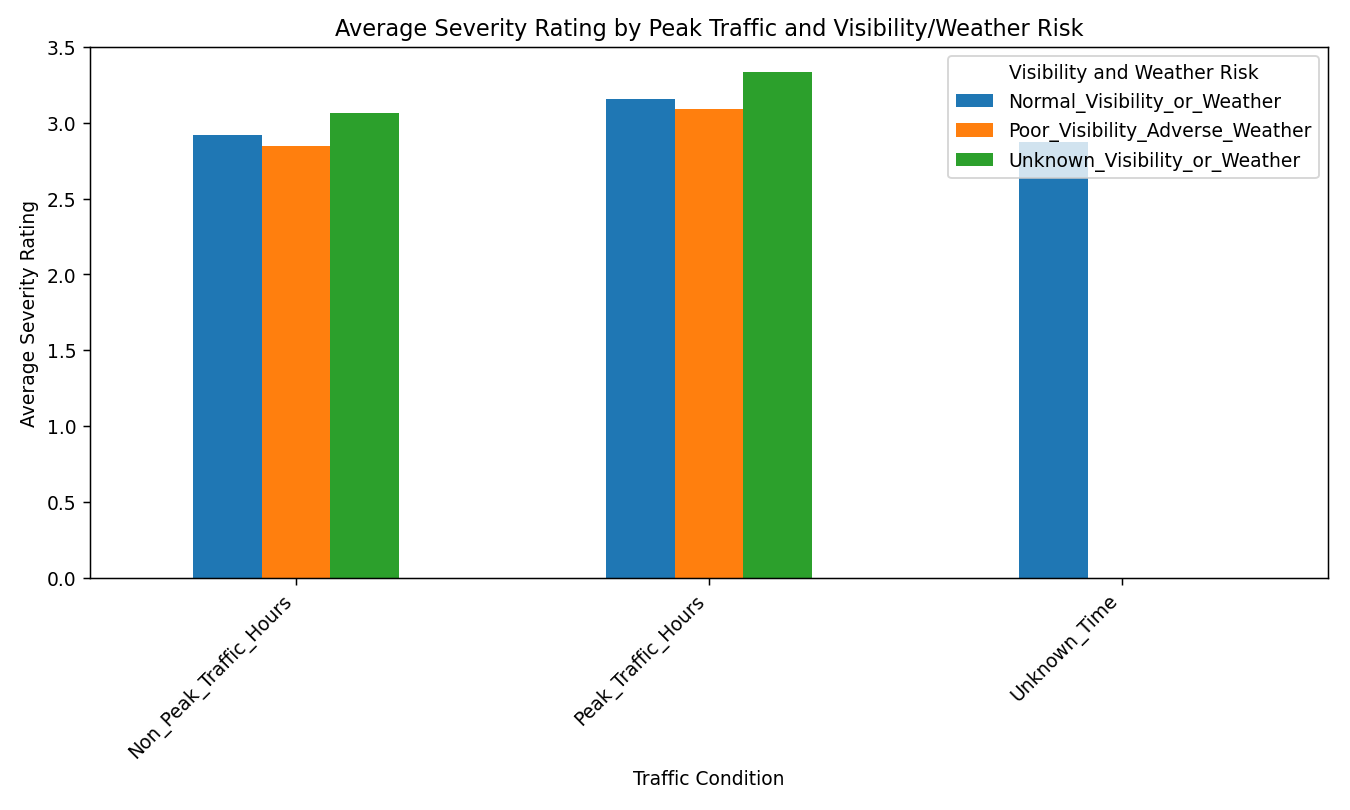

In [37]:
# Create grouped bar chart
plot1_pivot = plot1_pd.pivot(
    index="Peak_Traffic",
    columns="Visibility_Weather_Risk",
    values="avg_severity_rating"
)

plot1_pivot.plot(kind="bar", figsize=(10, 6))

plt.title("Average Severity Rating by Peak Traffic and Visibility/Weather Risk")
plt.xlabel("Traffic Condition")
plt.ylabel("Average Severity Rating")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Visibility and Weather Risk")
plt.tight_layout()
plt.savefig("plot1_peak_visibility_weather.png", dpi=300, bbox_inches="tight") # Save plot as image
plt.show()

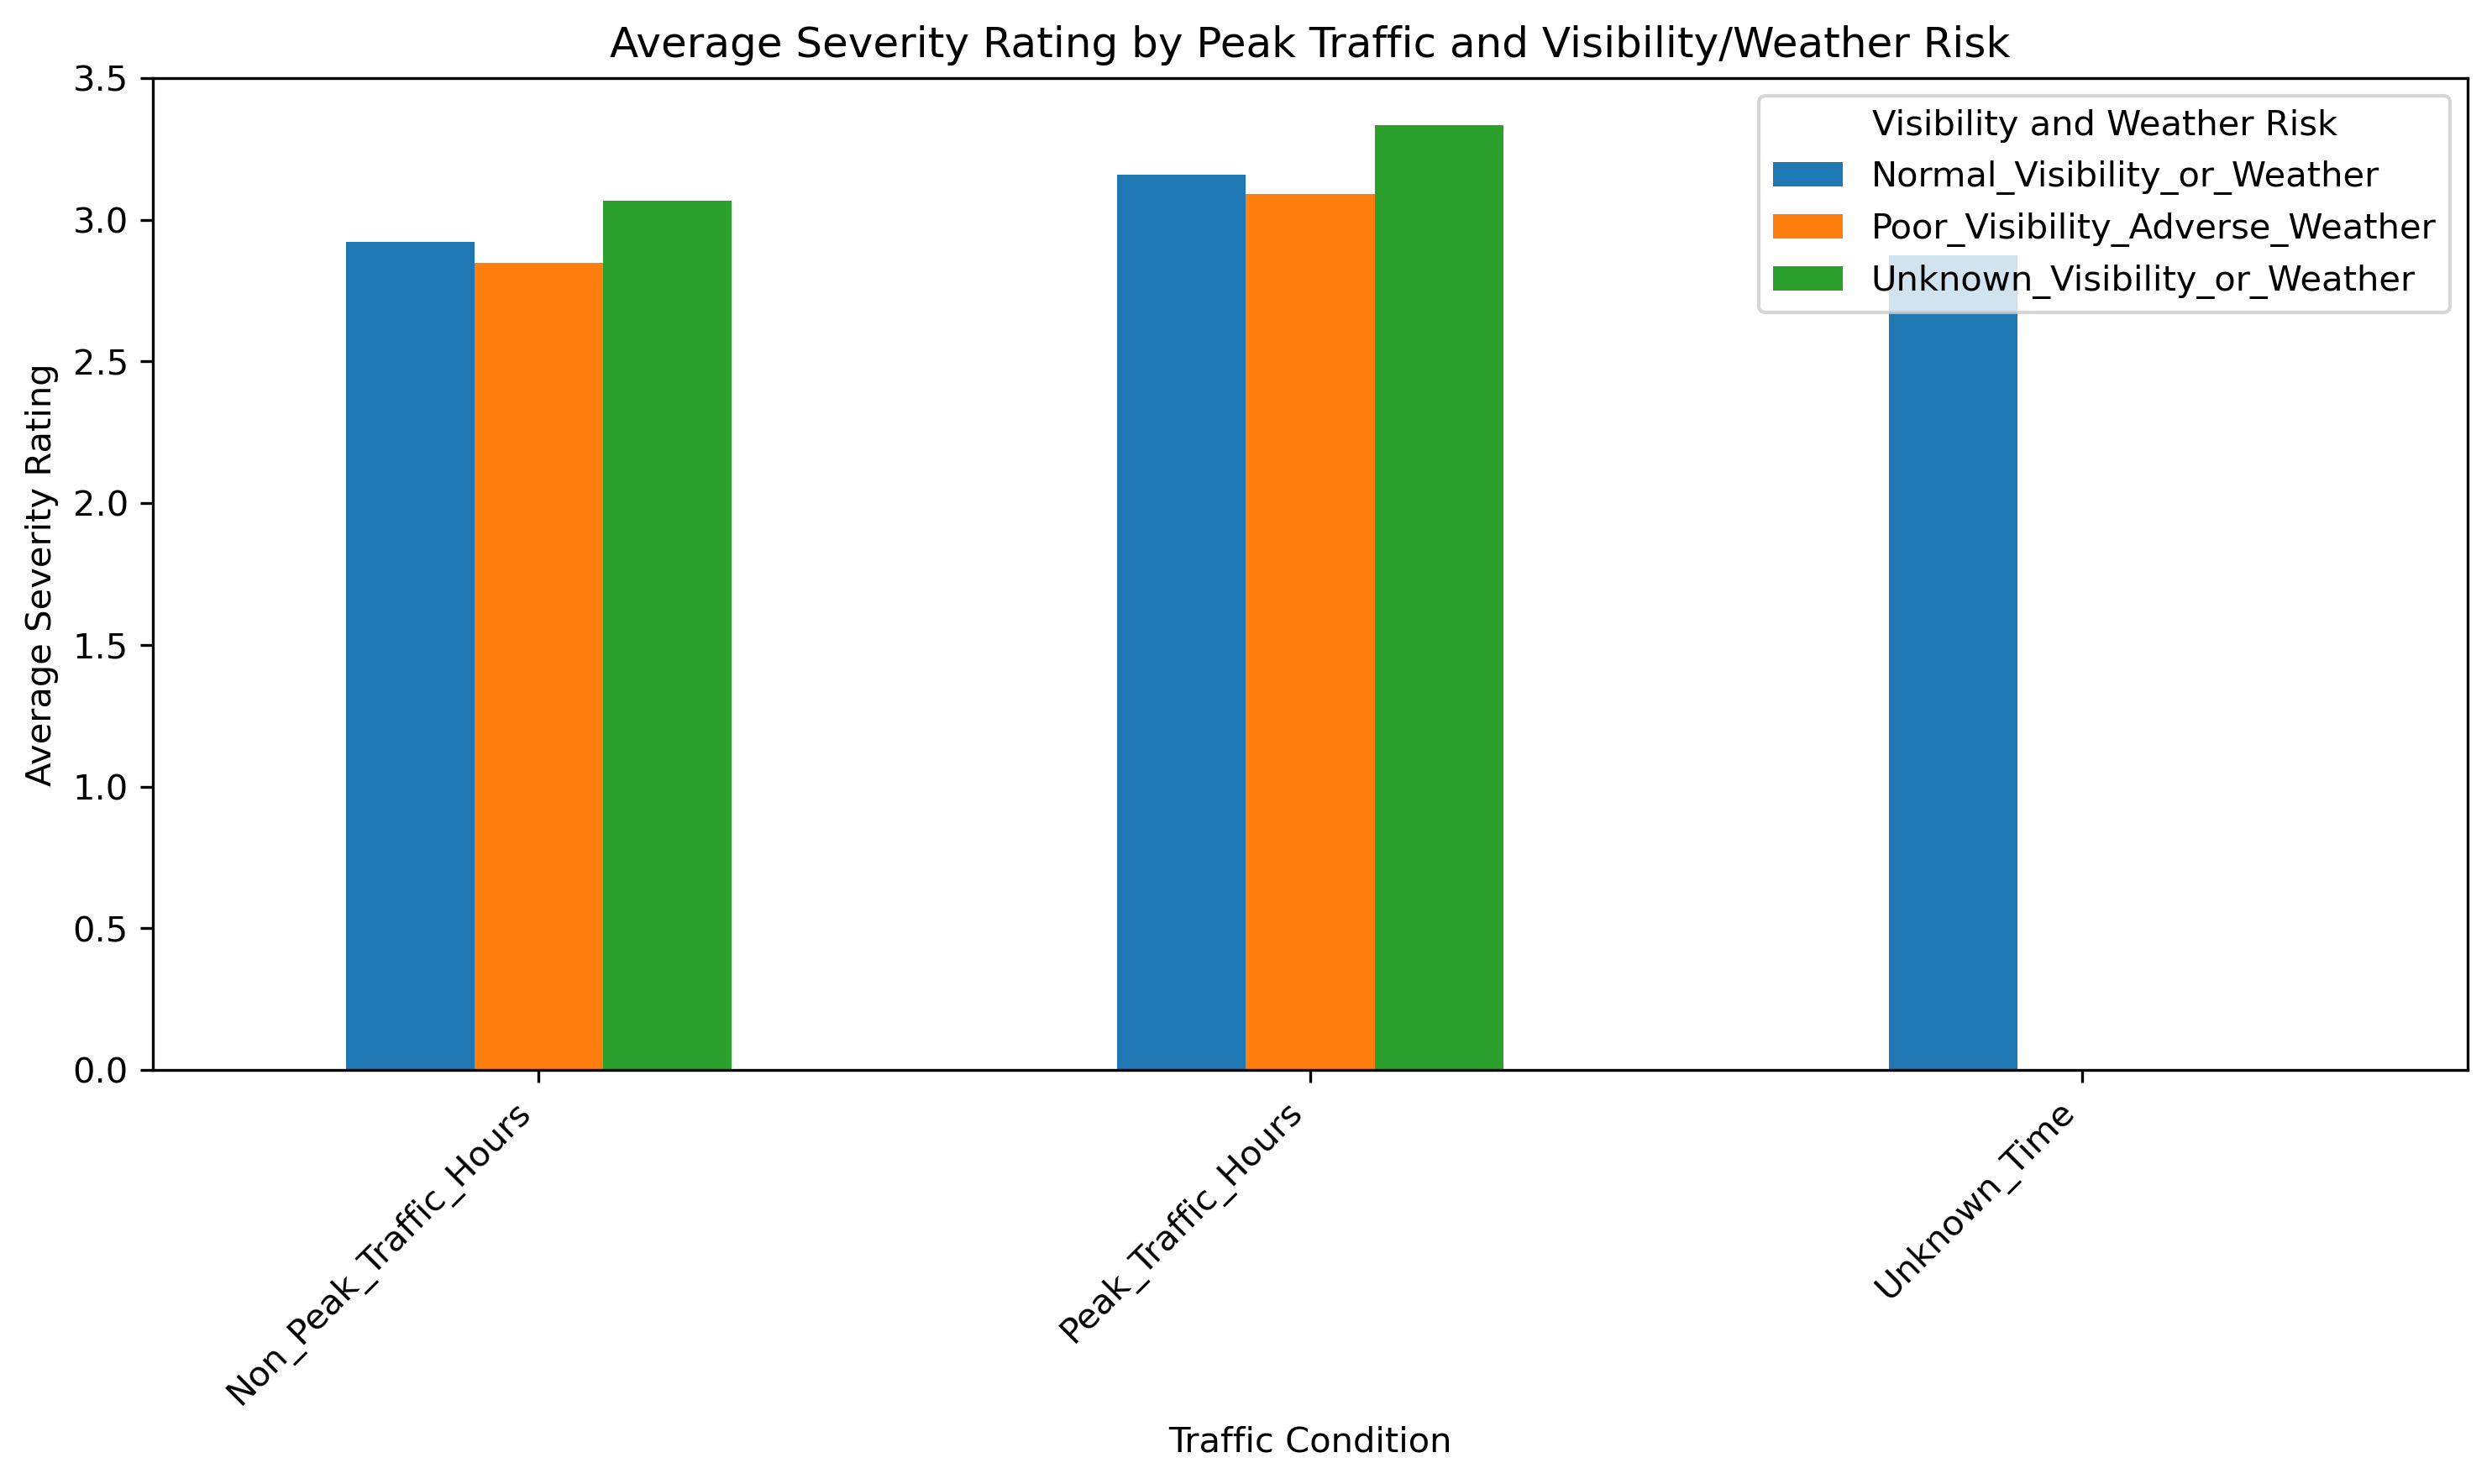

In [38]:
display(Image(filename="plot1_peak_visibility_weather.png"))

The above graph shows that the average severity rating in the categories Peak_Traffic and Visibility_Weather_Risk is significantly higher during peak traffic hours compared to non-peak traffic hours for both types of conditions. For instance, for normal visibility and weather, the average severity for peak traffic hours is 3.160 while the average for non-peak traffic hours is 2.921. Similarly, for Poor_Visibility_Adverse_Weather, the average severity is 3.090 for peak hours, while that of non-peak hours is 2.849. The highest average severity rating occurs in category Unknown_Visibility_or_Weather with peak traffic hours being 3.334. Average severity ratings are almost around 3, indicating that the data is skewed towards low severity crashes. This information should be considered later when selecting evaluation metrics and model strategy.

In [39]:
# Create urban/rural label from urban_or_rural_area attribute for plotting
feature_df_plot = df_featured.withColumn(
    "Urban_Rural_Label",
    F.when(F.col("urban_or_rural_area") == 1, "Urban")
     .when(F.col("urban_or_rural_area") == 2, "Rural")
     .when(F.col("urban_or_rural_area") == 3, "Unallocated")
     .otherwise("Unknown")
)

# Aggregate collision count and severity rating by speed limit and urban/rural area
plot2_df = (
    feature_df_plot
    .groupBy("speed_limit", "Urban_Rural_Label")
    .agg(
        F.count("*").alias("collision_count"),
        F.avg("label").alias("avg_severity_rating")
    )
    .orderBy("speed_limit", "Urban_Rural_Label")
)

plot2_pd = plot2_df.toPandas()
plot2_pd

,speed_limit,Urban_Rural_Label,collision_count,avg_severity_rating
0,20,Rural,7760,3.286598
1,20,Unallocated,71,2.887324
2,20,Unknown,808,2.533416
3,20,Urban,136701,3.385586
4,30,Rural,417644,3.383997
5,30,Unallocated,3882,3.138846
6,30,Unknown,2531249,2.400790
7,30,Urban,2930466,3.370115
8,40,Rural,171909,3.530531
9,40,Unallocated,641,3.230889


<IPython.core.display.Javascript object>


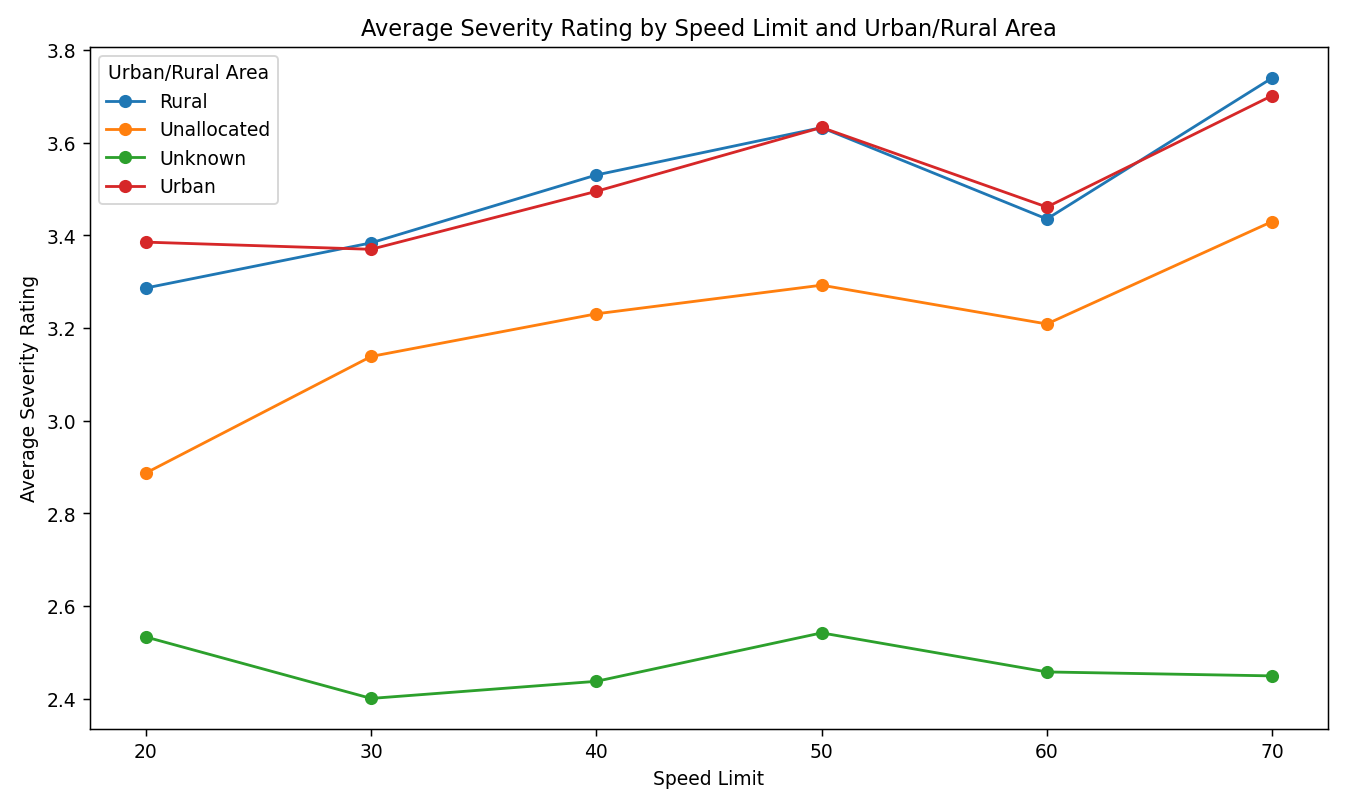

In [40]:
# Create line chart
plot2_pivot = plot2_pd.pivot(
    index="speed_limit",
    columns="Urban_Rural_Label",
    values="avg_severity_rating"
)

plot2_pivot.plot(kind="line", marker="o", figsize=(10, 6))

plt.title("Average Severity Rating by Speed Limit and Urban/Rural Area")
plt.xlabel("Speed Limit")
plt.ylabel("Average Severity Rating")
plt.xticks([20, 30, 40, 50, 60, 70])
plt.legend(title="Urban/Rural Area")
plt.tight_layout()
plt.show()
plt.savefig("plot2_speed_limit_urban_rural.png", dpi=300, bbox_inches="tight") # Save plot as image
plt.show()

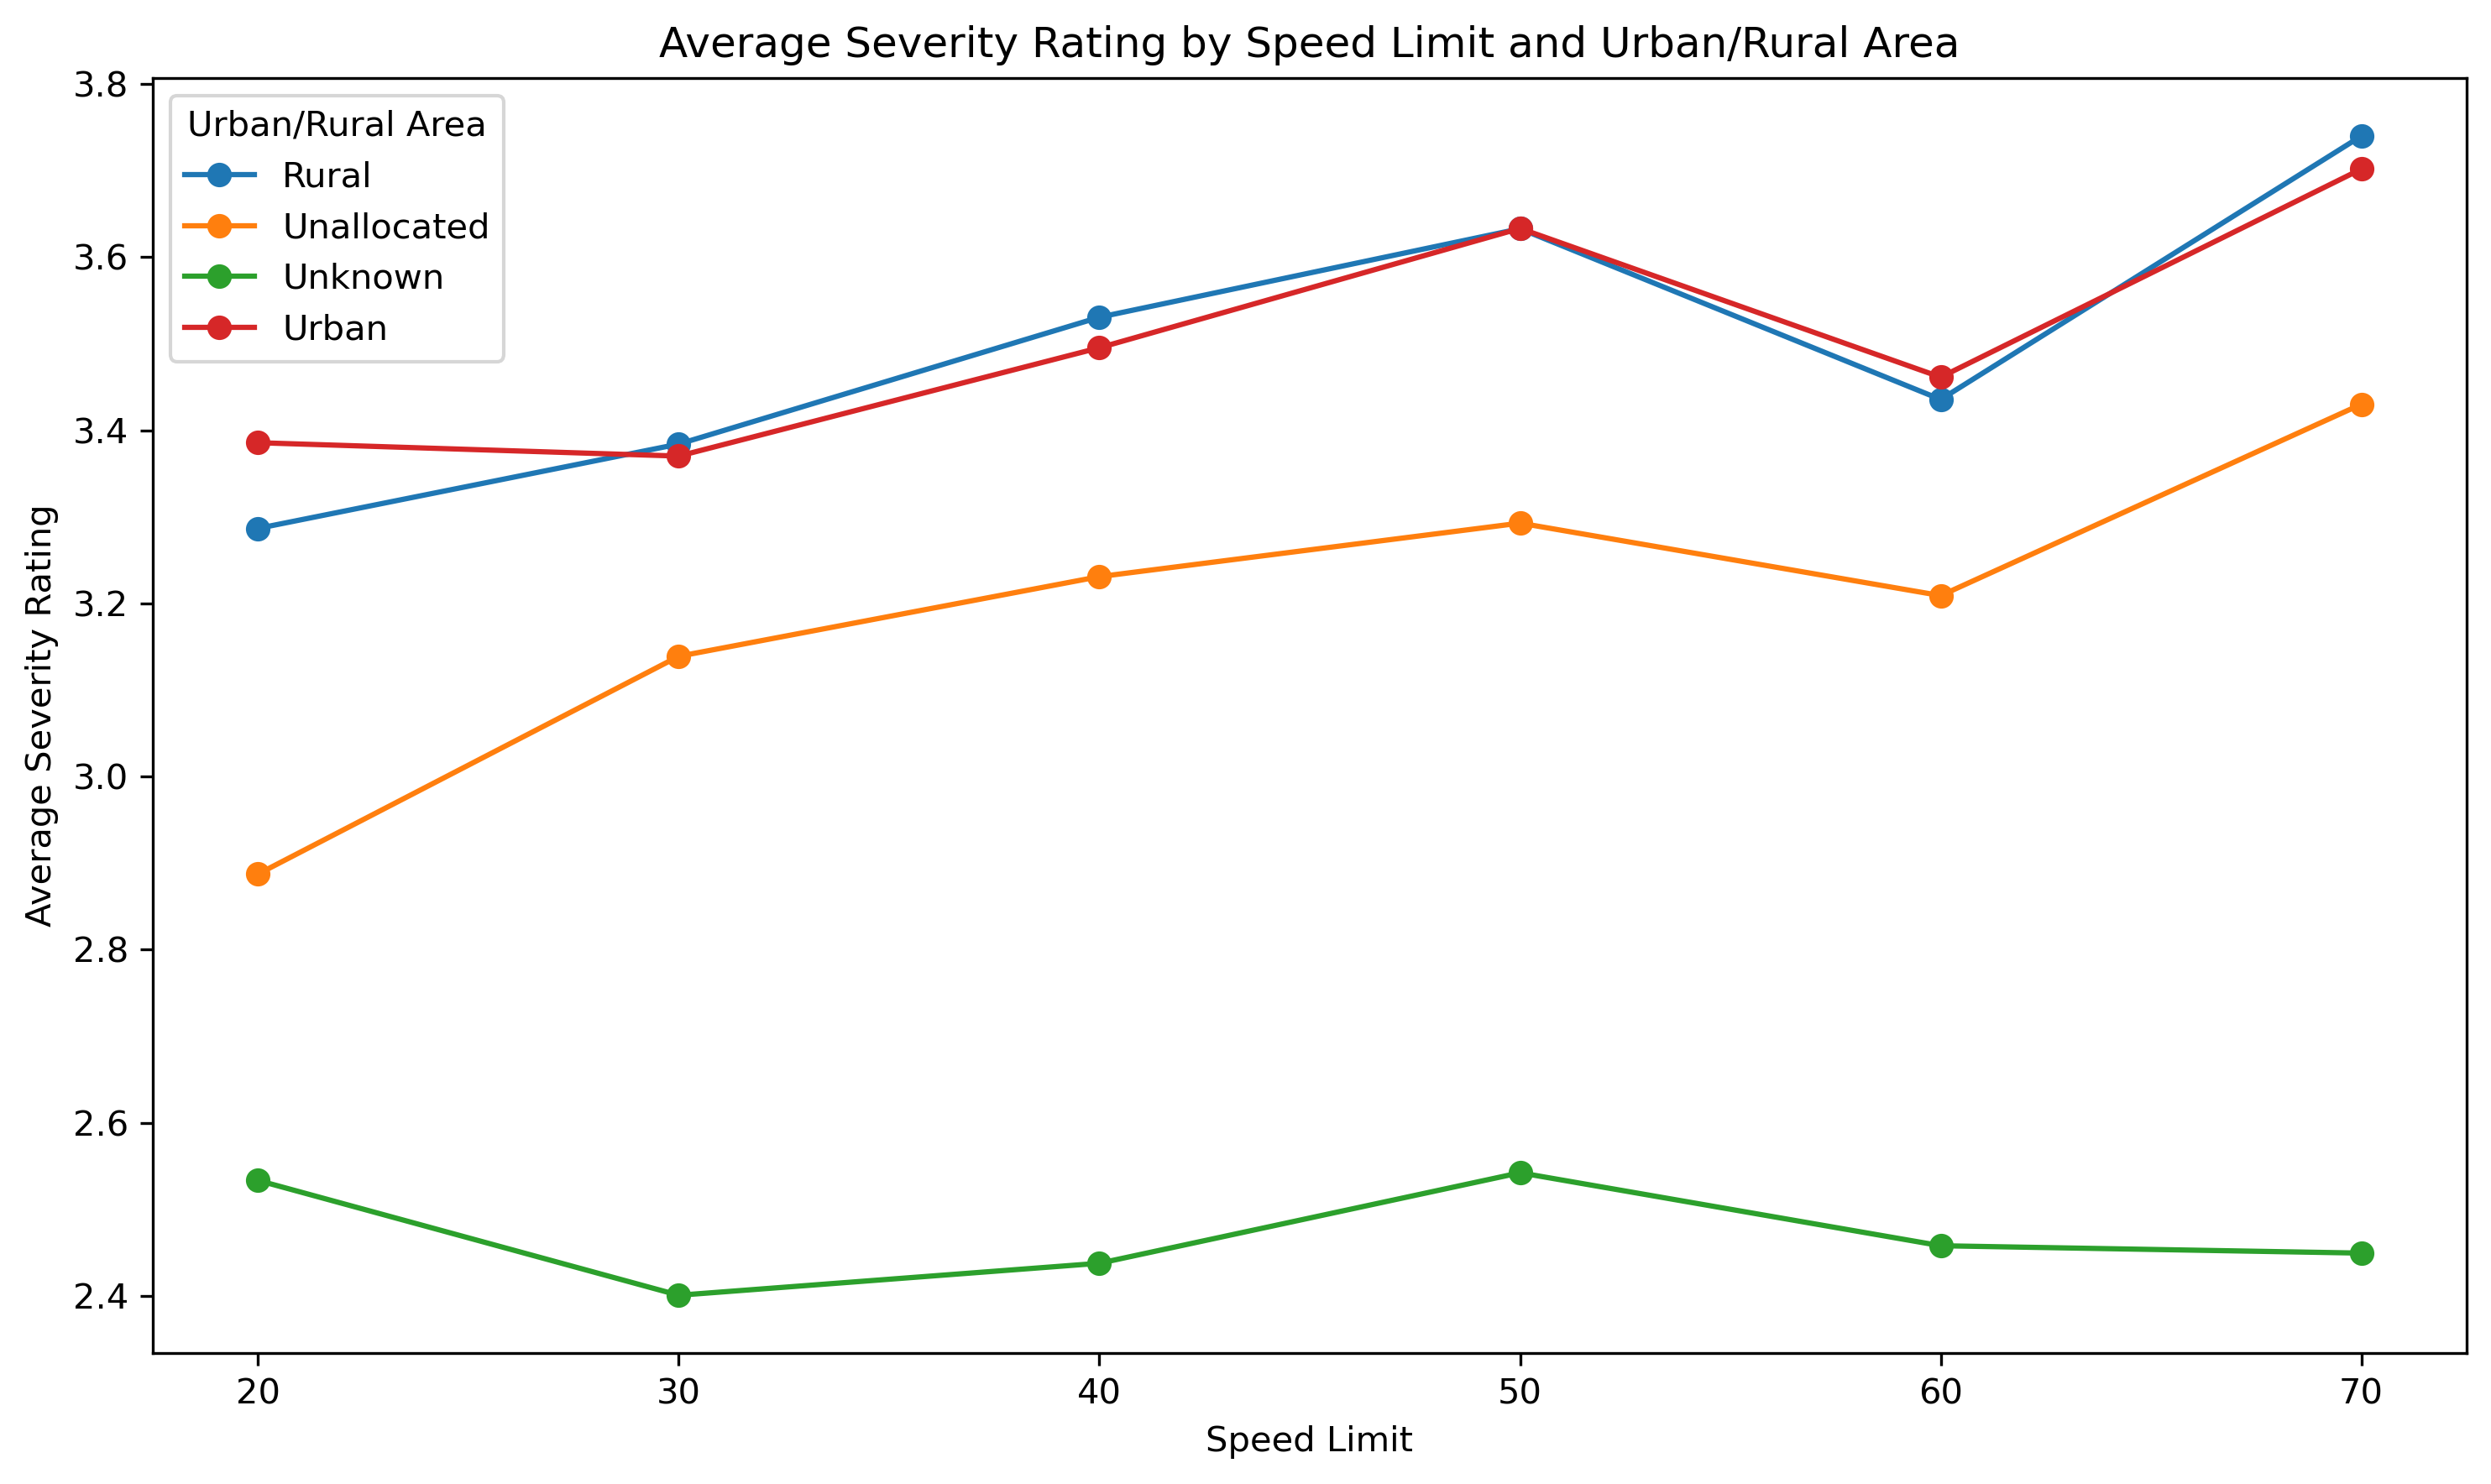

In [41]:
display(Image(filename="plot2_speed_limit_urban_rural.png"))

The plot describes the average severity rating depending on the speed limit and urban/rural classification based on pre-crash road context features. Generally, the greater the speed limit, the higher the average severity rating; however, this tendency is observed more significantly in rural areas. On rural roads, the values start from 3.287 (20 kmph) and gradually rise to 3.740 (70 kmph). Urban roads also have rather high severity values but not depending on speed limits, except for the last one, which is equal to 3.702. For unknown urban/rural records, the average severity values range between 2.4 and 2.5 and are noticeably lower. The average values of severity labels are generally much lower than their maximum possible value (10), which means the data is biased towards low severity accidents.

## Part 2. Feature extraction and ML training <a class="anchor" name="part-2"></a>
In this section, you must use PySpark DataFrame functions and ML packages for data preparation, model building, and evaluation. Other ML packages, such as scikit-learn, should not be used to process the data; however, it’s fine to use them to display the result or evaluate your model.  
### 2.1 Discuss the feature selection and prepare the feature columns

2.1.1 Based on the data exploration from 1.2 and considering the use case, discuss the importance of those features (For example, which features may be useless and should be removed, which feature has a significant impact on the label column, which should be transformed), which features you are planning to use? Discuss the reasons for selecting them and how you plan to create/transform them.  
○	300 words max for the discussion  
○	Please only use the provided data for model building  
○	You can create/add additional features based on the dataset  
○	Hint - Use the insights from the data exploration/domain knowledge/statistical models to consider whether to create more feature columns, whether to remove some columns  

In selecting the predictors for model training, I chose mainly the pre-crash and early-observable predictors since the application will be used for predicting the severity of accidents in the emergency response phase. Road context predictors such as speed_limit, road_type, junction_detail, junction_control, pedestrian_crossing, road_surface_conditions, carriageway_hazards, and urban_or_rural_area were chosen since the design of the road, speed conditions, and complexity of the junctions might influence the severity of crashes. 

Predictors such as light_conditions and weather_conditions were included since poor lighting, weather conditions such as rain, snow, and slippery roads could impact the severity of collisions. Latitude, longitude, and area were also included as predictors since the severity of accidents varies according to geographical location, depending on different road structures and emergency service accessibility.

The two engineering features include Hour and Peak_Traffic created from the time feature to measure commuting hour traffic. The feature Visibility_Weather_Risk was developed to detect any accidents caused by poor visibility and unfavorable weather conditions through the combination of light_conditions and weather_conditions.

The post-crash or high-leakage variables that include casualty_count, min_casualty_severity, max_casualty_severity, avg_casualty_severity, and casualty severity classes are all to be eliminated from model training because they can only be detected after the accident has occurred. Features like collision_index are to be dropped since they act more like identifiers and not predictors. Indexing and encoding will be performed on categorical variables and assembly on numeric variables.

2.1.2 Write code to create/transform the columns based on your discussion above.

In [42]:
# Columns to be excluded from modelling

# Identifier, raw date, and time columns cannot be used as model features
identifier_cols = [
    "collision_index",
    "date",
    "time"
]

# Post-crash and leakage-prone casualty attributes are to be excluded
post_crash_cols = [
    "casualty_count",
    "min_casualty_severity",
    "max_casualty_severity",
    "avg_casualty_severity",
    "driver_casualty_count",
    "passenger_casualty_count",
    "pedestrian_casualty_count",
    "car_passenger_count"
]

In [43]:
# Select the Categorical feature columns
categorical_cols = [
    "road_type",
    "junction_detail",
    "junction_control",
    "pedestrian_crossing",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "carriageway_hazards",
    "urban_or_rural_area",
    "area",
    "Peak_Traffic",
    "Visibility_Weather_Risk"
]

# Select the Numeric feature columns
numeric_cols = [
    "longitude",
    "latitude",
    "speed_limit",
    "vehicle_count",
    "avg_age_of_driver",
    "min_age_of_driver",
    "max_age_of_driver",
    "avg_age_of_vehicle",
    "skidding_vehicle_count",
    "male_driver_count",
    "female_driver_count",
    "unknown_driver_sex_count",
    "young_driver_count",
    "motorcycle_count",
    "goods_vehicle_count",
    "car_count",
    "bus_minibus_count",
    "turning_vehicle_count",
    "overtaking_vehicle_count",
    "vehicle_at_junction_count",
    "Hour"
]

# Select the target label column
label_col = "label"

In [44]:
# Keep only selected features and label
selected_cols = [label_col] + numeric_cols + categorical_cols

final_df = df_featured.select(selected_cols)

In [45]:
# Create missing-value indicator columns before handling missing values
final_df = final_df.withColumn(
    "location_missing",
    F.when(
        F.col("longitude").isNull() | F.col("latitude").isNull(),
        1
    ).otherwise(0)
)

final_df = final_df.withColumn(
    "driver_age_missing",
    F.when(F.col("avg_age_of_driver").isNull(), 1).otherwise(0)
)

final_df = final_df.withColumn(
    "vehicle_age_missing",
    F.when(F.col("avg_age_of_vehicle").isNull(), 1).otherwise(0)
)

# Calculate mean longitude and latitude by area
area_location_mean = (
    final_df
    .where(
        F.col("area").isNotNull() &
        F.col("longitude").isNotNull() &
        F.col("latitude").isNotNull()
    )
    .groupBy("area")
    .agg(
        F.avg("longitude").alias("area_mean_longitude"),
        F.avg("latitude").alias("area_mean_latitude")
    )
)

# Calculate global mean longitude and latitude as a backup
global_location_mean = (
    final_df
    .where(
        F.col("longitude").isNotNull() &
        F.col("latitude").isNotNull()
    )
    .agg(
        F.avg("longitude").alias("global_mean_longitude"),
        F.avg("latitude").alias("global_mean_latitude")
    )
    .first()
)

global_mean_longitude = global_location_mean["global_mean_longitude"]
global_mean_latitude = global_location_mean["global_mean_latitude"]

# Fill missing longitude and latitude using area mean first, then global mean
final_df = (
    final_df
    .join(area_location_mean, on="area", how="left")
    .withColumn(
        "longitude",
        F.when(
            F.col("longitude").isNull(),
            F.coalesce(
                F.col("area_mean_longitude"),
                F.lit(global_mean_longitude)
            )
        ).otherwise(F.col("longitude"))
    )
    .withColumn(
        "latitude",
        F.when(
            F.col("latitude").isNull(),
            F.coalesce(
                F.col("area_mean_latitude"),
                F.lit(global_mean_latitude)
            )
        ).otherwise(F.col("latitude"))
    )
    .drop("area_mean_longitude", "area_mean_latitude")
)

# Find the most common valid hour
most_common_hour = (
    final_df
    .where(F.col("Hour").isNotNull())
    .groupBy("Hour")
    .count()
    .orderBy(F.desc("count"))
    .first()[0]
)

# Fill missing Hour with the most common valid hour
final_df = final_df.withColumn(
    "Hour",
    F.when(
        F.col("Hour").isNull(),
        F.lit(most_common_hour)
    ).otherwise(F.col("Hour"))
)

# Approximate median imputation for age-related numeric columns
age_cols = [
    "avg_age_of_driver",
    "min_age_of_driver",
    "max_age_of_driver",
    "avg_age_of_vehicle"
]

age_medians = {}

for col_name in age_cols:
    median_value = final_df.approxQuantile(
        col_name,
        [0.5],
        0.01
    )[0]

    age_medians[col_name] = median_value

print("Age column medians:")
print(age_medians)

# Fill missing age values using approximate medians
final_df = final_df.fillna(age_medians)

# Fill categorical/code null values
final_df = final_df.fillna({
    "weather_conditions": 0,
    "road_type": 0,
    "urban_or_rural_area": 3
})

# Add missing-value indicators to numeric feature list
numeric_cols = numeric_cols + [
    "location_missing",
    "driver_age_missing",
    "vehicle_age_missing"
]

Age column medians:
{'avg_age_of_driver': 35.0, 'min_age_of_driver': 28.0, 'max_age_of_driver': 40.0, 'avg_age_of_vehicle': 6.5}


In [46]:
# Check missing values after handling nulls in smaller batches
batch_size = 8

for i in range(0, len(final_df.columns), batch_size):
    batch_cols = final_df.columns[i:i + batch_size]
    
    print("Null check for columns:")
    print(batch_cols)
    
    final_df.select([
        F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in batch_cols
    ]).show(truncate=False)

Null check for columns:
['area', 'label', 'longitude', 'latitude', 'speed_limit', 'vehicle_count', 'avg_age_of_driver', 'min_age_of_driver']
+----+-----+---------+--------+-----------+-------------+-----------------+-----------------+
|area|label|longitude|latitude|speed_limit|vehicle_count|avg_age_of_driver|min_age_of_driver|
+----+-----+---------+--------+-----------+-------------+-----------------+-----------------+
|0   |0    |0        |0       |0          |0            |0                |0                |
+----+-----+---------+--------+-----------+-------------+-----------------+-----------------+

Null check for columns:
['max_age_of_driver', 'avg_age_of_vehicle', 'skidding_vehicle_count', 'male_driver_count', 'female_driver_count', 'unknown_driver_sex_count', 'young_driver_count', 'motorcycle_count']
+-----------------+------------------+----------------------+-----------------+-------------------+------------------------+------------------+----------------+
|max_age_of_driver|

### 2.2 Preparing Spark ML Transformers/Estimators for features, labels, and models  <a class="anchor" name="2.2"></a>

** Write code to create Transformers/Estimators for transforming/assembling the columns you selected above in 2.1 and create ML model Estimators for Random Forest (RF) and Gradient-boosted tree (GBT) model.
Please DO NOT fit/transform the data yet.**

In [47]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor
from pyspark.sql import functions as F

# Cast the label attribute to double data type for regression models
final_df = final_df.withColumn("label", F.col("label").cast("double"))

# Define the categorical columns to be used as features
categorical_cols = [
    "road_type",
    "junction_detail",
    "junction_control",
    "pedestrian_crossing",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "carriageway_hazards",
    "urban_or_rural_area",
    "area",
    "Peak_Traffic",
    "Visibility_Weather_Risk"
]

# Define the numerical columns to be used as features
numeric_cols = [
    "longitude",
    "latitude",
    "speed_limit",
    "vehicle_count",
    "avg_age_of_driver",
    "min_age_of_driver",
    "max_age_of_driver",
    "avg_age_of_vehicle",
    "skidding_vehicle_count",
    "male_driver_count",
    "female_driver_count",
    "unknown_driver_sex_count",
    "young_driver_count",
    "motorcycle_count",
    "goods_vehicle_count",
    "car_count",
    "bus_minibus_count",
    "turning_vehicle_count",
    "overtaking_vehicle_count",
    "vehicle_at_junction_count",
    "Hour",
    "location_missing",
    "driver_age_missing",
    "vehicle_age_missing"
]

# Convert values in categorical columns to strings for proper usage of StringIndexer
for col_name in categorical_cols:
    final_df = final_df.withColumn(col_name, F.col(col_name).cast("string"))

# Use StringIndexer and store the values on index columns
indexed_cols = [col + "_index" for col in categorical_cols]

indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=col + "_index",
        handleInvalid="keep"
    )
    for col in categorical_cols
]

# Use OneHotEncoder on top of indexed categorical columns
encoded_cols = [col + "_encoded" for col in categorical_cols]

encoder = OneHotEncoder(
    inputCols=indexed_cols,
    outputCols=encoded_cols,
    handleInvalid="keep"
)

# Assemble all the numeric and encoded categorical columns into one feature vector
assembler = VectorAssembler(
    inputCols=numeric_cols + encoded_cols,
    outputCol="features",
    handleInvalid="keep"
)

# Random Forest regression estimator
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    seed=2026
)

# Gradient-Boosted Tree regression estimator
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    seed=2026
)

# Pipeline for Random Forest
rf_pipeline = Pipeline(stages=indexers + [encoder, assembler, rf])

# Pipeline for Gradient-Boosted Tree
gbt_pipeline = Pipeline(stages=indexers + [encoder, assembler, gbt])

Justify your choice of using a regression model or multi-class classification model.

Regression was used because the severity rating is an ordinal value ranging from 1 to 10. In the case of the regression algorithm, the ordering will be preserved. This means that a closer prediction will have a lower penalty than a farther one. For a multi-class classification model, there would be no concept of how close each label category could be to each other.

StringIndexer and OneHotEncoder will be used for categorical variables like road type, weather conditions, light conditions, area, peak traffic, and visibility weather risk. For numeric variables such as longitude, latitude, speed limit, vehicle count, skidding vehicle count, hit object vehicle count, and hour, there will be no transformations applied before assembly into feature vectors. There will be two different pipelines with a RandomForestRegressor and GBTRegressor.

** Write code to include the above Transformers/Estimators into two pipelines.
Please DO NOT fit/transform the data yet.**

### 2.3 Training and evaluating models  
2.3.1 Write code to split the data for training and testing, using 2026 as the random seed.

In [48]:
# Create sampling fractions for each label value
label_fractions = {
    row["label"]: 0.2
    for row in final_df.select("label").distinct().collect()
}

# Take 20% stratified sample by label to reduce memory usage while preserving label distribution
sampled_df = final_df.sampleBy(
    col="label",
    fractions=label_fractions,
    seed=2026
)

# Cache sampled data because it will be reused for train/test split and model training
sampled_df = sampled_df.cache()

print("Sampled rows:", sampled_df.count())

Sampled rows: 1801557


In [49]:
# Check label distribution in sampled data
sampled_df.groupBy("label") \
    .count() \
    .orderBy("label") \
    .show()

+-----+------+
|label| count|
+-----+------+
|  1.0| 45770|
|  2.0|605362|
|  3.0|611981|
|  4.0|401361|
|  5.0|101889|
|  6.0| 29028|
|  7.0|  5091|
|  8.0|   905|
|  9.0|   137|
| 10.0|    33|
+-----+------+



2.3.2 Decide which metric is the best and implement the evaluation process.

As severity_rating has been considered a numeric value between 1 to 10, regression metrics will be used for model assessment. RMSE will be used as it gives more weightage to larger errors that could lead to higher losses while estimating the severity of accidents. MAE will also be used to measure the average error made in estimation. R² value would be used as well, showing the proportion of the variance in the target variable that is explained by the independent variables in the model. The better performing model will be chosen according to RMSE with MAE and R² as support metrics.

2.3.3 Train, evaluate and Save the better model (you’ll need it for A2B).
(Note: You may need to go through a few training loops or use more data to create a better-performing model.)

In [50]:
# Split the sampled data into training and testing sets using 70/30 split
train_df, test_df = sampled_df.randomSplit([0.7, 0.3], seed=2026)

train_df = train_df.cache()
test_df = test_df.cache()

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())

Training rows: 1260912
Testing rows: 540645


In [51]:
# Fit the training data into Random Forest Pipeline
rf_model = rf_pipeline.fit(train_df)

# Make predictions on the testing data
rf_predictions = rf_model.transform(test_df)

# Display the sample predictions
rf_predictions.select("label", "prediction").show(10)

+-----+------------------+
|label|        prediction|
+-----+------------------+
|  1.0| 2.214780037984454|
|  1.0|2.1875403726247225|
|  1.0| 2.168963056929498|
|  1.0|  2.21134437260375|
|  1.0|  2.11841308274128|
|  1.0| 2.170788603161525|
|  1.0| 2.172786386730149|
|  1.0|2.2170158295367535|
|  1.0| 2.189987402581756|
|  1.0|2.1833566665312136|
+-----+------------------+
only showing top 10 rows


In [52]:
# Fit the training data into Gradient-Boosted Tree Pipeline
gbt_model = gbt_pipeline.fit(train_df)

# Make predictions on the testing data
gbt_predictions = gbt_model.transform(test_df)

# Display the sample predictions
gbt_predictions.select("label", "prediction").show(10)

+-----+------------------+
|label|        prediction|
+-----+------------------+
|  1.0|1.6736778505720618|
|  1.0| 2.066854013207537|
|  1.0|2.0805765067099276|
|  1.0| 1.830395936131942|
|  1.0|1.8033279051649005|
|  1.0|2.1150301084028555|
|  1.0|1.5911490033544777|
|  1.0|1.8047279893329529|
|  1.0|2.3214163091882942|
|  1.0| 2.127847654343365|
+-----+------------------+
only showing top 10 rows


In [53]:
from pyspark.ml.evaluation import RegressionEvaluator

# Create the evaluators
rmse_evaluator = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="mae"
)

r2_evaluator = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="r2"
)

# Evaluate Random Forest model
rf_rmse = rmse_evaluator.evaluate(rf_predictions)
rf_mae = mae_evaluator.evaluate(rf_predictions)
rf_r2 = r2_evaluator.evaluate(rf_predictions)

# Evaluate GBT model
gbt_rmse = rmse_evaluator.evaluate(gbt_predictions)
gbt_mae = mae_evaluator.evaluate(gbt_predictions)
gbt_r2 = r2_evaluator.evaluate(gbt_predictions)

print("Random Forest Regression Results")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2:", rf_r2)

print("\nGradient-Boosted Tree Regression Results")
print("RMSE:", gbt_rmse)
print("MAE:", gbt_mae)
print("R2:", gbt_r2)

Random Forest Regression Results
RMSE: 0.6435509123600639
MAE: 0.47184818670966255
R2: 0.620585205793432

Gradient-Boosted Tree Regression Results
RMSE: 0.5986824154820316
MAE: 0.42993978618340223
R2: 0.6716466551229374


In [54]:
# Create model comparison dataframe
model_results = spark.createDataFrame([
    ("Random Forest", float(rf_rmse), float(rf_mae), float(rf_r2)),
    ("Gradient-Boosted Tree", float(gbt_rmse), float(gbt_mae), float(gbt_r2))
], ["model", "rmse", "mae", "r2"])

model_results.show(truncate=False)

+---------------------+------------------+-------------------+------------------+
|model                |rmse              |mae                |r2                |
+---------------------+------------------+-------------------+------------------+
|Random Forest        |0.6435509123600639|0.47184818670966255|0.620585205793432 |
|Gradient-Boosted Tree|0.5986824154820316|0.42993978618340223|0.6716466551229374|
+---------------------+------------------+-------------------+------------------+



In [55]:
# Select the better model based on lower RMSE
if rf_rmse <= gbt_rmse:
    best_model = rf_model
    best_model_name = "Random Forest"
    best_rmse = rf_rmse
else:
    best_model = gbt_model
    best_model_name = "Gradient-Boosted Tree"
    best_rmse = gbt_rmse

print("Best model:", best_model_name)
print("Best RMSE:", best_rmse)

# Save the better model for Assignment 2B
best_model_path = "A2A/best_severity_regression_model"

best_model.write().overwrite().save(best_model_path)

print("Best model saved to:", best_model_path)

Best model: Gradient-Boosted Tree
Best RMSE: 0.5986824154820316
Best model saved to: A2A/best_severity_regression_model


### Part 3. Hyperparameter Tuning and Model Optimisation <a class="anchor" name="part-3"></a>  
Apply the techniques you have learnt from the labs, for example, CrossValidator, TrainValidationSplit, ParamGridBuilder, etc., to perform further hyperparameter tuning and model optimisation.  
The assessment is based on the quality of your work/process, not the quality of your model. Please include your thoughts/ideas/discussions.

In [56]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import RegressionEvaluator

# Evaluator for tuning
tuning_evaluator = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="rmse"
)

# Small GBT parameter grid
gbt_param_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [4, 5, 6])
    .addGrid(gbt.maxIter, [20, 30])
    .addGrid(gbt.stepSize, [0.05, 0.1])
    .build()
)

print("Number of parameter combinations:", len(gbt_param_grid))

# TrainValidationSplit is lighter than CrossValidator
gbt_tvs = TrainValidationSplit(
    estimator=gbt_pipeline,
    estimatorParamMaps=gbt_param_grid,
    evaluator=tuning_evaluator,
    trainRatio=0.8,
    seed=2026,
    parallelism=1
)

# Fit tuned model
gbt_tuned_model = gbt_tvs.fit(train_df)

# Predict on test set
gbt_tuned_predictions = gbt_tuned_model.transform(test_df)

# Evaluate tuned model
gbt_tuned_rmse = rmse_evaluator.evaluate(gbt_tuned_predictions)
gbt_tuned_mae = mae_evaluator.evaluate(gbt_tuned_predictions)
gbt_tuned_r2 = r2_evaluator.evaluate(gbt_tuned_predictions)

print("Tuned Gradient-Boosted Tree Regression Results")
print("RMSE:", gbt_tuned_rmse)
print("MAE:", gbt_tuned_mae)
print("R2:", gbt_tuned_r2)

Number of parameter combinations: 12
Tuned Gradient-Boosted Tree Regression Results
RMSE: 0.590456544070003
MAE: 0.4205717322618289
R2: 0.6806077889792331


In [57]:
tuning_results = spark.createDataFrame([
    ("Baseline GBT", float(gbt_rmse), float(gbt_mae), float(gbt_r2)),
    ("Tuned GBT", float(gbt_tuned_rmse), float(gbt_tuned_mae), float(gbt_tuned_r2))
], ["model", "rmse", "mae", "r2"])

tuning_results.show(truncate=False)

+------------+------------------+-------------------+------------------+
|model       |rmse              |mae                |r2                |
+------------+------------------+-------------------+------------------+
|Baseline GBT|0.5986824154820316|0.42993978618340223|0.6716466551229374|
|Tuned GBT   |0.590456544070003 |0.4205717322618289 |0.6806077889792331|
+------------+------------------+-------------------+------------------+



In [58]:
# Save the tuned GBT model as the final best model
final_best_model = gbt_tuned_model.bestModel
final_best_model_name = "Tuned Gradient-Boosted Tree"

final_best_model_path = "A2A/final_best_severity_model"

final_best_model.write().overwrite().save(final_best_model_path)

print("Final best model:", final_best_model_name)
print("Final best model saved to:", final_best_model_path)

Final best model: Tuned Gradient-Boosted Tree
Final best model saved to: A2A/final_best_severity_model


For the task of hyperparameters tuning, the Gradient-Boosted Tree regression model was chosen because it had outperformed Random Forest in part 2. TrainValidationSplit was favored more when compared with Cross Validator to decrease the computational cost on the large dataset. RMSE metric was used in the hyperparameter tuning process since the label severity_rating had been considered as a regression label and RMSE penalises prediction errors in a more strong manner.

Three parameters have been tuned: maxDepth, maxIter and stepSize. The parameter maxDepth tunes the complexity of the trees, maxIter is the number of boosting iterations and stepSize defines the learning rate. Tested parameters were: maxDepth: [4,5,6]; maxIter:[20,30]; stepSize:[0.05,0.1]. Thus, we have had 12 parameter combinations.

Having been tuned, the model has shown some improvements compared to the baseline GBT model. RMSE has been improved from 0.5981 to 0.5903; MAE has been improved from 0.4308 to 0.4212; and the score R² has been improved from 0.6720 to 0.6805. It means that the tuned GBT model made lesser prediction errors and could explain slightly more variation in the label severity_rating. As far as all the evaluation metrics have been improved, the tuned model can be accepted.

## References:
Please add your references below:

Apache Spark. (2026). PySpark Documentation. Apache Spark. https://spark.apache.org/docs/latest/api/python/index.html

Apache Spark. (2026). MLlib: Extracting, transforming and selecting features. Apache Spark. https://spark.apache.org/docs/latest/ml-features.html

Apache Spark. (2026). MLlib: Classification and regression. Apache Spark. https://spark.apache.org/docs/latest/ml-classification-regression.html